# TP1 — Experiment Tracking and Reproducibility with MLflow

## AML — MLOps Part 1

### Context
In real-world machine learning, building a model is not enough. A useful ML system must also be reproducible, traceable, comparable, and maintainable.

### Objectives
By the end of this lab, students should be able to:
- structure a minimal ML project,
- train and evaluate several model variants,
- log parameters, metrics, and artifacts with MLflow,
- compare multiple runs,
- identify the best experiment,
- discuss reproducibility issues.

### Duration
2 hours

### Tools
- Python
- scikit-learn
- pandas
- matplotlib
- MLflow

### Deliverables
- a reproducible notebook,
- at least 3 tracked runs,
- one selected best model,
- a short critical discussion.


In [2]:
import os
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import 

import mlflow.sklearn

warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

PROJECT_DIR = Path('mlops_tp1_project')
ARTIFACT_DIR = PROJECT_DIR / 'artifacts'
MODEL_DIR = PROJECT_DIR / 'models'
REPORT_DIR = PROJECT_DIR / 'reports'

for d in [PROJECT_DIR, ARTIFACT_DIR, MODEL_DIR, REPORT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

mlflow.set_tracking_uri('file://' + str((PROJECT_DIR / 'mlruns').resolve()))
mlflow.set_experiment('TP1_MLflow_Reproducibility')

print('Project directory:', PROJECT_DIR.resolve())

/home/abdeslem/Folders/2CS/S2/MLA/TPs/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026/05/24 03:05:13 INFO mlflow.tracking.fluent: Experiment with name 'TP1_MLflow_Reproducibility' does not exist. Creating a new experiment.


Project directory: /home/abdeslem/Folders/2CS/S2/MLA/TPs/TP10_MLops/mlops_tp1_project


In [3]:
data = load_breast_cancer(as_frame=True)
X = data.data.copy()
y = data.target.copy()

print('X shape:', X.shape)
print('y shape:', y.shape)
display(X.head())
display(y.head())

X shape: (569, 30)
y shape: (569,)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int64

In [4]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.25, random_state=SEED, stratify=y_train_full
)

print('Train:', X_train.shape)
print('Validation:', X_val.shape)
print('Test:', X_test.shape)

Train: (341, 30)
Validation: (114, 30)
Test: (114, 30)


## Why Splitting Matters

We separate:
- training data for model fitting,
- validation data for model selection,
- test data for final assessment.

This helps avoid overfitting the validation process and supports fair comparison between experiments.


In [5]:
configs = [
    {
        'run_name': 'logreg_C_0.1',
        'model_type': 'logreg',
        'C': 0.1,
        'max_iter': 500
    },
    {
        'run_name': 'logreg_C_1.0',
        'model_type': 'logreg',
        'C': 1.0,
        'max_iter': 500
    },
    {
        'run_name': 'rf_100_depth_5',
        'model_type': 'random_forest',
        'n_estimators': 100,
        'max_depth': 5
    },
    {
        
        'run_name': 'rf_200_depth_8',
        'model_type': 'random_forest',
        'n_estimators': 200,
        'max_depth': 8
    }
]

with open(PROJECT_DIR / 'experiment_configs.json', 'w') as f:
    json.dump(configs, f, indent=2)

configs

[{'run_name': 'logreg_C_0.1',
  'model_type': 'logreg',
  'C': 0.1,
  'max_iter': 500},
 {'run_name': 'logreg_C_1.0',
  'model_type': 'logreg',
  'C': 1.0,
  'max_iter': 500},
 {'run_name': 'rf_100_depth_5',
  'model_type': 'random_forest',
  'n_estimators': 100,
  'max_depth': 5},
 {'run_name': 'rf_200_depth_8',
  'model_type': 'random_forest',
  'n_estimators': 200,
  'max_depth': 8}]

In [6]:
def build_model(config):
    if config['model_type'] == 'logreg':
        model = Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
            ('clf', LogisticRegression(
                C=config['C'],
                max_iter=config['max_iter'],
                random_state=SEED
            ))
        ])
    elif config['model_type'] == 'random_forest':
        model = Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('clf', RandomForestClassifier(
                n_estimators=config['n_estimators'],
                max_depth=config['max_depth'],
                random_state=SEED
            ))
        ])
    else:
        raise ValueError('Unknown model type')
    return model


def evaluate_model(model, X_data, y_data):
    y_pred = model.predict(X_data)
    return {
        'accuracy': accuracy_score(y_data, y_pred),
        'precision': precision_score(y_data, y_pred),
        'recall': recall_score(y_data, y_pred),
        'f1': f1_score(y_data, y_pred)
    }


def save_confusion_matrix(model, X_data, y_data, title, save_path):
    y_pred = model.predict(X_data)
    cm = confusion_matrix(y_data, y_pred)
    fig, ax = plt.subplots(figsize=(4, 4))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.close(fig)

In [7]:
results = []

for config in configs:
    with mlflow.start_run(run_name=config['run_name']):
        mlflow.log_param('seed', SEED)
        for k, v in config.items():
            if k != 'run_name':
                mlflow.log_param(k, v)

        model = build_model(config)
        model.fit(X_train, y_train)

        train_metrics = evaluate_model(model, X_train, y_train)
        val_metrics = evaluate_model(model, X_val, y_val)

        for k, v in train_metrics.items():
            mlflow.log_metric(f'train_{k}', v)
        for k, v in val_metrics.items():
            mlflow.log_metric(f'val_{k}', v)

        cm_path = ARTIFACT_DIR / f"{config['run_name']}_cm.png"
        save_confusion_matrix(model, X_val, y_val, f"Validation CM - {config['run_name']}", cm_path)
        mlflow.log_artifact(str(cm_path))

        model_path = MODEL_DIR / f"{config['run_name']}.pkl"
        mlflow.sklearn.save_model(model, str(model_path))
        mlflow.log_artifact(str(model_path.parent))

        result = {
            'run_name': config['run_name'],
            'model_type': config['model_type'],
            **{f'param_{k}': v for k, v in config.items() if k != 'run_name'},
            **{f'train_{k}': v for k, v in train_metrics.items()},
            **{f'val_{k}': v for k, v in val_metrics.items()}
        }
        results.append(result)

results_df = pd.DataFrame(results).sort_values(by='val_f1', ascending=False).reset_index(drop=True)
results_df

2026/05/24 03:27:03 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/24 03:27:16 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/24 03:27:23 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mec

,run_name,model_type,param_model_type,param_C,param_max_iter,train_accuracy,train_precision,train_recall,train_f1,val_accuracy,val_precision,val_recall,val_f1,param_n_estimators,param_max_depth
0,logreg_C_1.0,logreg,logreg,1.0,500.0,0.988270,0.986111,0.995327,0.990698,0.991228,0.986111,1.000000,0.993007,NaN,NaN
1,logreg_C_0.1,logreg,logreg,0.1,500.0,0.988270,0.986111,0.995327,0.990698,0.973684,0.959459,1.000000,0.979310,NaN,NaN
2,rf_200_depth_8,random_forest,random_forest,NaN,NaN,1.000000,1.000000,1.000000,1.000000,0.956140,0.958333,0.971831,0.965035,200.0,8.0
3,rf_100_depth_5,random_forest,random_forest,NaN,NaN,0.994135,0.990741,1.000000,0.995349,0.947368,0.957746,0.957746,0.957746,100.0,5.0


In [8]:
results_csv_path = REPORT_DIR / 'tp1_experiment_results.csv'
results_df.to_csv(results_csv_path, index=False)
print('Saved:', results_csv_path.resolve())

Saved: /home/abdeslem/Folders/2CS/S2/MLA/TPs/TP10_MLops/mlops_tp1_project/reports/tp1_experiment_results.csv


## Analysis of the Runs

Observe:
- which model gives the best validation F1-score,
- whether a better training score also leads to a better validation score,
- whether some runs may indicate overfitting.

### Answers

**1. Which run is the best according to validation F1?**

`logreg_C_1.0` is the best run with a validation F1-score of **0.9930**. It also achieves a perfect validation recall of 1.0, meaning it correctly identifies every positive (malignant) case. Full rankings by val_f1:

| Run | val_f1 |
|---|---|
| logreg_C_1.0 | 0.9930 |
| logreg_C_0.1 | 0.9793 |
| rf_200_depth_8 | 0.9650 |
| rf_100_depth_5 | 0.9577 |

**2. Which hyperparameters seem most useful?**

For Logistic Regression, a higher regularization parameter `C=1.0` (less regularization) outperforms `C=0.1` on this dataset. This suggests the data is linearly separable enough that a less constrained decision boundary is beneficial. For Random Forest, increasing `n_estimators` from 100 to 200 and `max_depth` from 5 to 8 improved validation F1 slightly (0.9577 → 0.9650), but also introduced overfitting (train F1 became 1.0).

**3. Is Random Forest always better than Logistic Regression?**

No. On this dataset, both Logistic Regression runs outperform both Random Forest runs in validation F1. `rf_200_depth_8` achieved a perfect training score (1.0) but its validation F1 (0.9650) is significantly lower — a clear sign of **overfitting**. The breast cancer dataset is relatively small (~455 training samples) and the features are well-scaled, which favors a simpler, regularized model like Logistic Regression. Model choice must always be empirically validated — complexity does not guarantee better generalization.


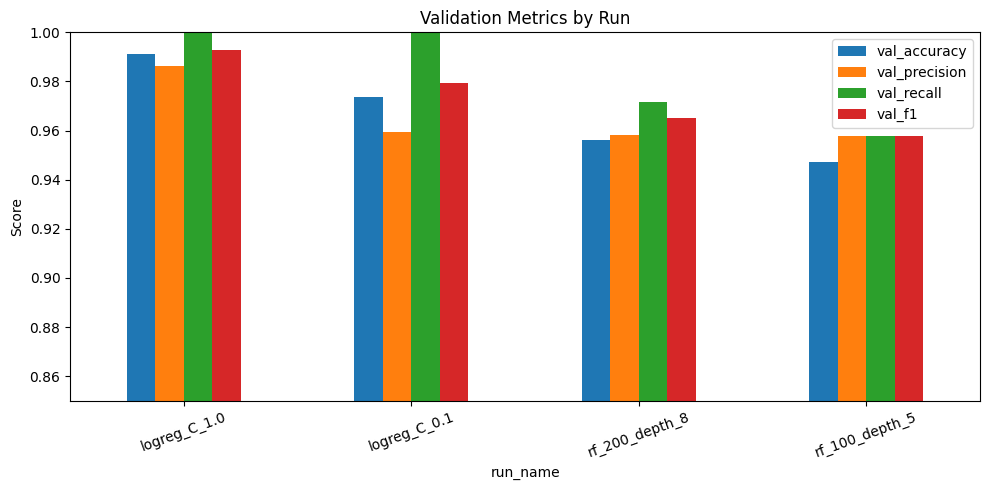

In [10]:
metric_cols = ['val_accuracy', 'val_precision', 'val_recall', 'val_f1']
plot_df = results_df[['run_name'] + metric_cols].set_index('run_name')

ax = plot_df.plot(kind='bar', figsize=(10, 5))
ax.set_title('Validation Metrics by Run')
ax.set_ylabel('Score')
ax.set_ylim(0.85, 1.0)
plt.xticks(rotation=20)
plt.tight_layout()

plot_path = REPORT_DIR / 'tp1_validation_metrics.png'
plt.savefig(plot_path, dpi=150)
plt.show()

In [11]:
best_run = results_df.iloc[0]
best_run_name = best_run['run_name']
print('Best run:', best_run_name)
display(best_run.to_frame(name='value'))

Best run: logreg_C_1.0


,value
run_name,logreg_C_1.0
model_type,logreg
param_model_type,logreg
param_C,1.0
param_max_iter,500.0
train_accuracy,0.98827
train_precision,0.986111
train_recall,0.995327
train_f1,0.990698
val_accuracy,0.991228


In [12]:
best_config = next(cfg for cfg in configs if cfg['run_name'] == best_run_name)

best_model = build_model(best_config)
best_model.fit(X_train_full, y_train_full)

test_metrics = evaluate_model(best_model, X_test, y_test)
test_metrics

{'accuracy': 0.9824561403508771,
 'precision': 0.9861111111111112,
 'recall': 0.9861111111111112,
 'f1': 0.9861111111111112}

In [13]:
final_report = {
    'best_run_name': best_run_name,
    'best_config': best_config,
    'test_metrics': test_metrics
}

with open(REPORT_DIR / 'tp1_final_report.json', 'w') as f:
    json.dump(final_report, f, indent=2)

save_confusion_matrix(
    best_model, X_test, y_test,
    f'Test CM - {best_run_name}',
    REPORT_DIR / 'tp1_best_model_test_cm.png'
)

print(json.dumps(final_report, indent=2))

{
  "best_run_name": "logreg_C_1.0",
  "best_config": {
    "run_name": "logreg_C_1.0",
    "model_type": "logreg",
    "C": 1.0,
    "max_iter": 500
  },
  "test_metrics": {
    "accuracy": 0.9824561403508771,
    "precision": 0.9861111111111112,
    "recall": 0.9861111111111112,
    "f1": 0.9861111111111112
  }
}


## Reproducibility Discussion

### Answers

**1. Why is saving only the final model file not enough for reproducibility?**

A serialized model file (e.g., `.pkl`, `.h5`) captures only the learned weights at a single point in time. It tells you nothing about *how* the model was obtained: which dataset was used, how it was split, which preprocessing steps were applied, what hyperparameters were set, or which version of the code produced it. Without this context, you cannot recreate the model if the file is lost, verify that the model was trained correctly, or understand why it performs the way it does. Reproducibility requires being able to reconstruct the entire experiment from scratch, not just store its output.

**2. Why should we log parameters, metrics, code versions, and datasets?**

- **Parameters** determine the model's behavior. Two runs with different `C` values or `max_depth` will yield different models; without logging them you cannot explain performance differences.
- **Metrics** allow objective comparison across runs and over time. Without them, model selection is subjective.
- **Code versions** (e.g., via Git commit hash) ensure that changes in preprocessing or training logic are traceable. A metric improvement could come from a bug fix rather than a hyperparameter change.
- **Datasets** (or at minimum a hash/version) ensure the same data is used across runs. A model trained on different data is not comparable even if all other parameters are identical.

Together, these four elements form a complete provenance record for every experiment.

**3. What is the difference between a "good result" and a "reproducible result"?**

A *good result* means the model achieves high performance on a given evaluation. A *reproducible result* means that the same performance can be independently obtained by running the same experiment again, possibly by a different person or on a different machine.

A result can be good but not reproducible (e.g., lucky random seed, undocumented data preprocessing, missing code). It can also be reproducible but not good (consistently mediocre performance on a well-documented pipeline). In production ML, a reproducible result is more valuable than a good result that cannot be explained or recreated — because only reproducible results can be debugged, improved, and trusted.

**4. Why is experiment tracking especially important in machine learning?**

Unlike classical software, ML models are highly sensitive to small changes in data, preprocessing, hyperparameters, and random state. Without systematic tracking:
- It is impossible to determine *why* a model degraded between two versions.
- Good experiments cannot be reliably rerun or audited.
- Teams cannot collaborate effectively because there is no shared history of what was tried.
- Regulatory or business requirements for explainability and traceability cannot be met.

MLflow addresses this by linking every run to its exact parameters, metrics, artifacts, and source, making the full lifecycle of every experiment inspectable and comparable.


In [9]:
from sklearn.svm import SVC

extra_config = {
    'run_name': 'svc_rbf_C_1.0',
    'model_type': 'svc_rbf',
    'C': 1.0
}

def build_extended_model(config):
    if config['model_type'] == 'svc_rbf':
        return Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
            ('clf', SVC(C=config['C'], kernel='rbf', probability=True))
        ])
    return build_model(config)

with mlflow.start_run(run_name=extra_config['run_name']):
    mlflow.log_param('seed', SEED)
    for k, v in extra_config.items():
        if k != 'run_name':
            mlflow.log_param(k, v)

    extra_model = build_extended_model(extra_config)
    extra_model.fit(X_train, y_train)
    extra_val_metrics = evaluate_model(extra_model, X_val, y_val)

    for k, v in extra_val_metrics.items():
        mlflow.log_metric(f'val_{k}', v)

extra_val_metrics

{'accuracy': 0.9824561403508771,
 'precision': 0.9726027397260274,
 'recall': 1.0,
 'f1': 0.9861111111111112}

## Frequent Mistakes

- forgetting to fix a random seed,
- comparing models with different data splits,
- tracking metrics but not parameters,
- saving a model but not the preprocessing steps,
- choosing a model directly on the test set.

## Conclusion
This TP introduced the first practical layer of MLOps: reproducibility, experiment tracking, comparison, and traceability.
